<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/revised_Age_Gender_Fairness_Aware_and_Uncertainty_Quantified_Ensemble_Models_for_Personalized_Heart_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ==================== INSTALL MISSING PACKAGES ====================
!pip install catboost shap -q

# ==================== IMPORT LIBRARIES ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap

# Plot settings
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")
print("✅ All libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00
✅ All libraries imported successfully!


In [4]:
# Mount Google Drive (if using Colab)
from google.colab import drive
drive.mount('/content/drive')

# Load data
df = pd.read_csv('/content/drive/MyDrive/Dataset/heart_disease_risk_dataset_earlymed.csv')

print("Dataset Shape:", df.shape)
print("\nTarget Distribution:")
print(df['Heart_Risk'].value_counts(normalize=True))
print("\nGender Distribution:")
print(df['Gender'].value_counts())
print("\nAge Statistics:")
print(df['Age'].describe())

df.head()

Mounted at /content/drive
Dataset Shape: (70000, 19)

Target Distribution:
Heart_Risk
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

Gender Distribution:
Gender
1.0    38425
0.0    31575
Name: count, dtype: int64

Age Statistics:
count    70000.000000
mean        54.461986
std         16.410794
min         20.000000
25%         45.000000
50%         56.000000
75%         67.000000
max         84.000000
Name: Age, dtype: float64


,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


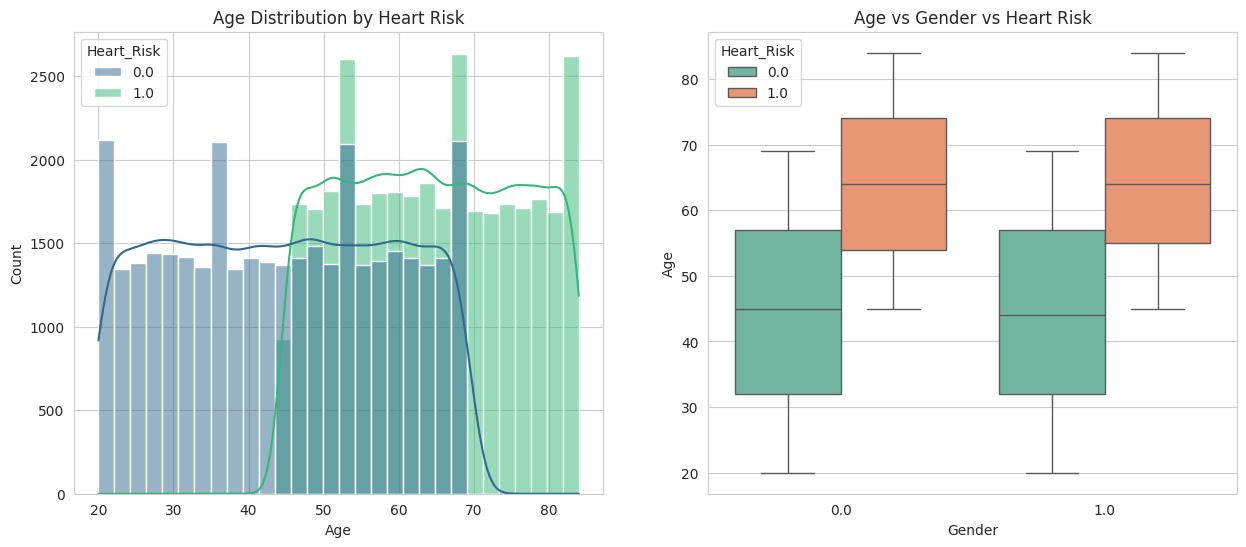

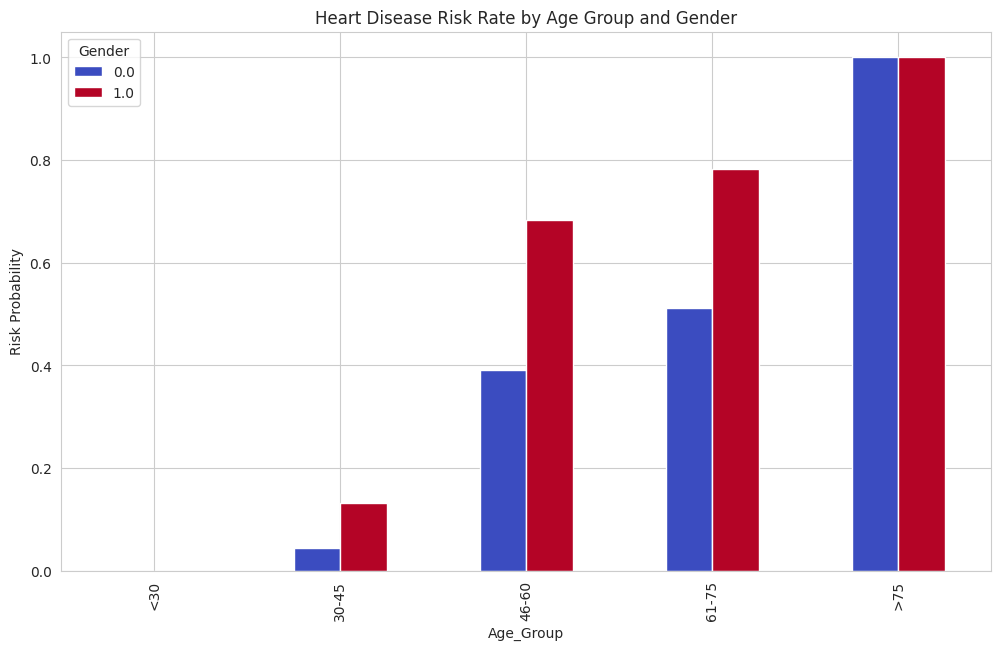

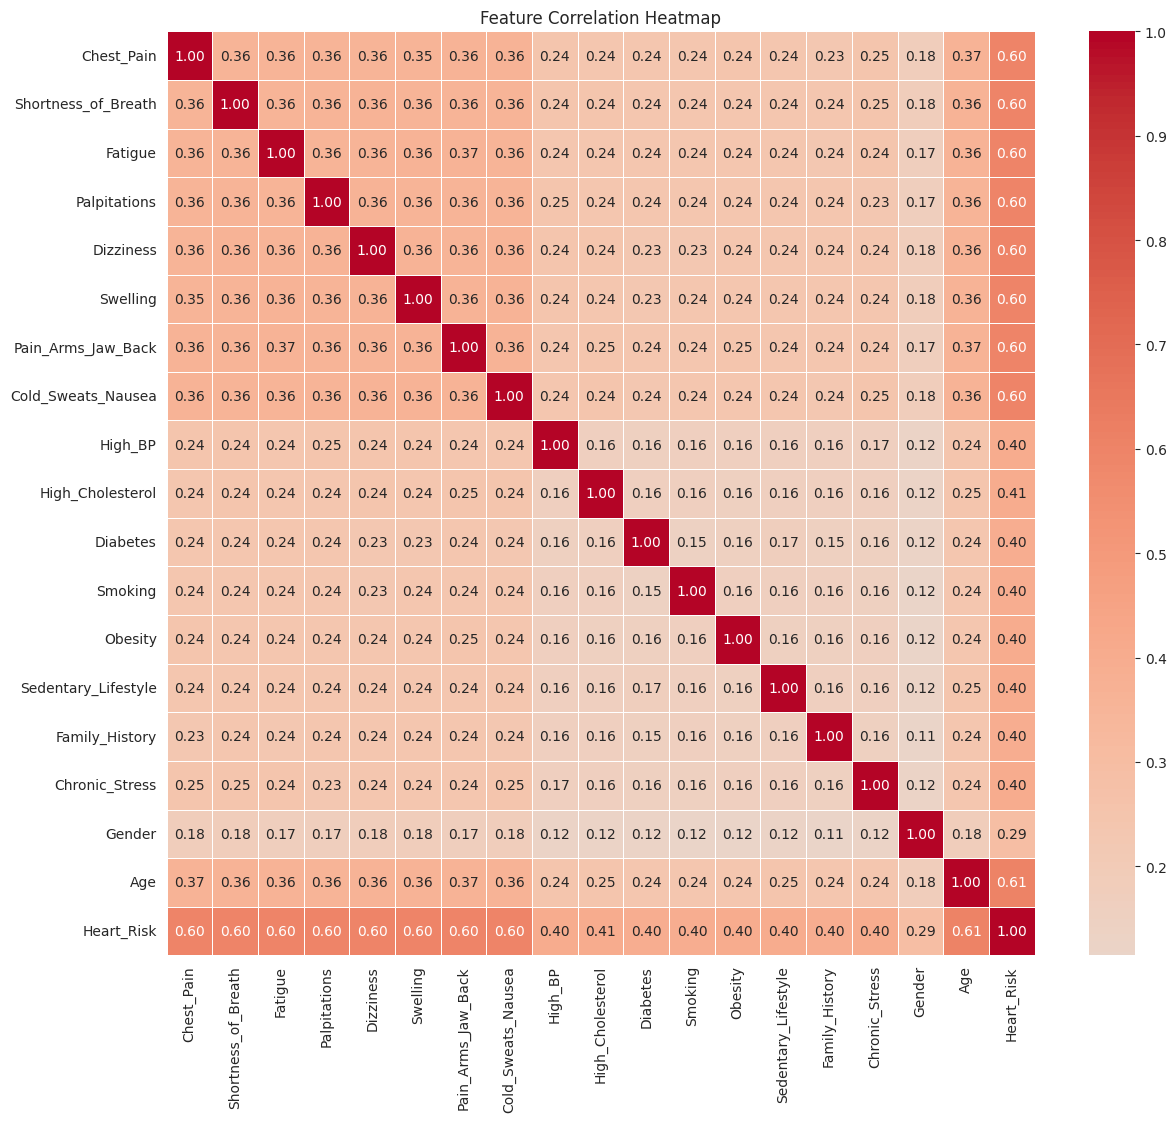

In [5]:
# Age Distribution by Heart Risk
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', hue='Heart_Risk', bins=30, kde=True, palette='viridis')
plt.title('Age Distribution by Heart Risk')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Gender', y='Age', hue='Heart_Risk', palette='Set2')
plt.title('Age vs Gender vs Heart Risk')
plt.show()

# Risk Rate by Age Group and Gender
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 45, 60, 75, 100],
                        labels=['<30', '30-45', '46-60', '61-75', '>75'])

risk_by_group = df.groupby(['Age_Group', 'Gender'])['Heart_Risk'].mean().unstack()
risk_by_group.plot(kind='bar', figsize=(12, 7), colormap='coolwarm')
plt.title('Heart Disease Risk Rate by Age Group and Gender')
plt.ylabel('Risk Probability')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(14, 12))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [6]:
X = df.drop(['Heart_Risk', 'Age_Group'], axis=1)
y = df['Heart_Risk']

# 75% Train, 25% Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y, shuffle=True
)

# Split Temp into Validation (10%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.6, random_state=42, stratify=y_temp, shuffle=True
)

print(f"Train shape     : {X_train.shape[0]:,} ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation shape: {X_val.shape[0]:,}  ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test shape      : {X_test.shape[0]:,}  ({X_test.shape[0]/len(df)*100:.1f}%)")

Train shape     : 52,500 (75.0%)
Validation shape: 7,000  (10.0%)
Test shape      : 10,500  (15.0%)


In [7]:
# Base Models
rf = RandomForestClassifier(n_estimators=400, max_depth=12, random_state=42, n_jobs=-1)
xgb_model = xgb.XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=8,
                              random_state=42, eval_metric='auc')
lgb_model = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, max_depth=8,
                               random_state=42, verbose=-1)

# Voting Ensemble
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb_model), ('lgb', lgb_model)],
    voting='soft'
)

# Calibrated Ensemble (Better Uncertainty)
calibrated_ensemble = CalibratedClassifierCV(ensemble, cv=5, method='isotonic')

# All Models Dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": rf,
    "XGBoost": xgb_model,
    "LightGBM": lgb_model,
    "CatBoost": CatBoostClassifier(iterations=400, learning_rate=0.05, depth=8,
                                   random_state=42, verbose=False),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=400,
                                                     learning_rate=0.05, max_depth=8, random_state=42),
    "Ensemble (Voting + Calibrated)": calibrated_ensemble
}

In [8]:
results = []

for name, model in models.items():
    print(f"Training {name}...")
    if name != "Ensemble (Voting + Calibrated)":
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_prob),
        'Precision': classification_report(y_test, y_pred, output_dict=True)['weighted avg']['precision'],
        'Recall': classification_report(y_test, y_pred, output_dict=True)['weighted avg']['recall']
    })

results_df = pd.DataFrame(results).round(4)
print("\n=== Model Performance Comparison ===")
print(results_df.sort_values('ROC_AUC', ascending=False))

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training LightGBM...
Training CatBoost...
Training Gradient Boosting...
Training Ensemble (Voting + Calibrated)...

=== Model Performance Comparison ===
                            Model  Accuracy  ROC_AUC  Precision  Recall
3                        LightGBM    0.9930   0.9997     0.9930  0.9930
4                        CatBoost    0.9928   0.9996     0.9928  0.9928
2                         XGBoost    0.9923   0.9996     0.9923  0.9923
5               Gradient Boosting    0.9928   0.9996     0.9928  0.9928
1                   Random Forest    0.9922   0.9995     0.9922  0.9922
0             Logistic Regression    0.9908   0.9994     0.9908  0.9908
6  Ensemble (Voting + Calibrated)    0.9928   0.9994     0.9928  0.9928


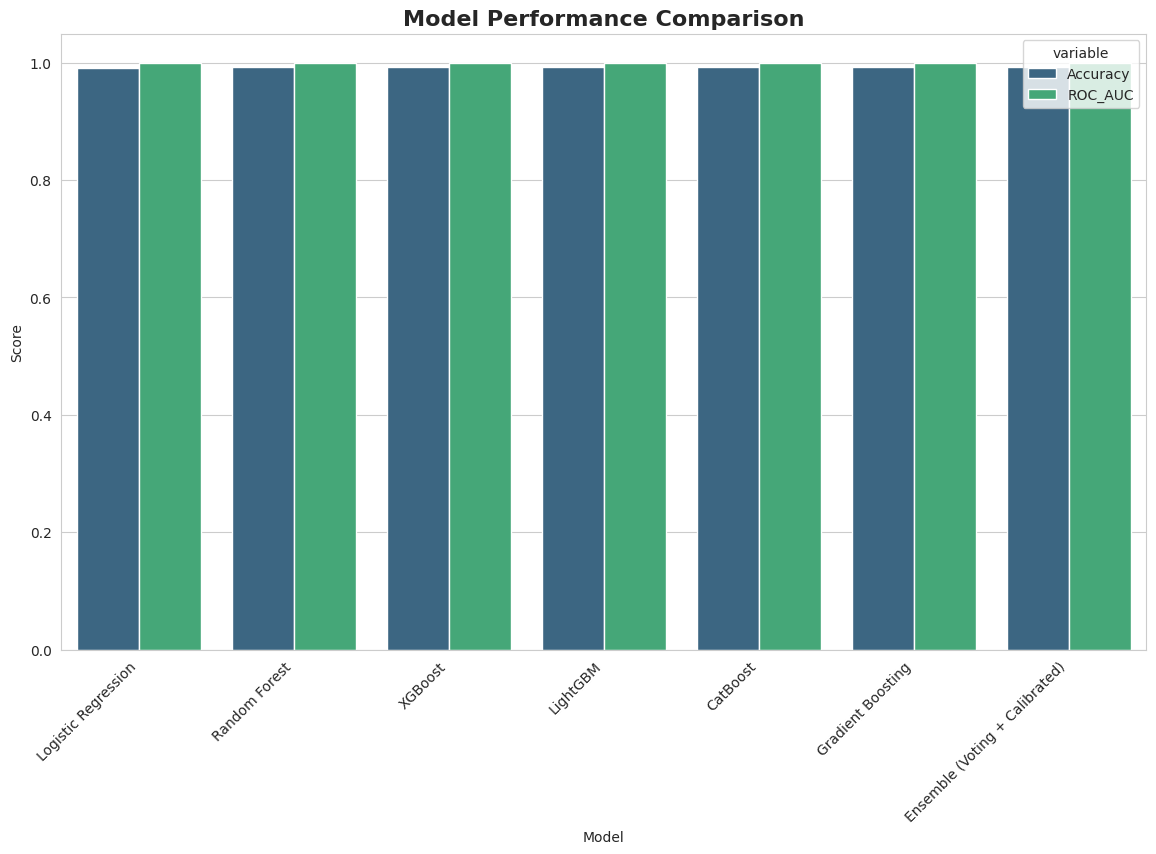

In [9]:
plt.figure(figsize=(14, 8))
results_melt = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'ROC_AUC'])
sns.barplot(data=results_melt, x='Model', y='value', hue='variable', palette='viridis')
plt.title('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Score')
plt.show()

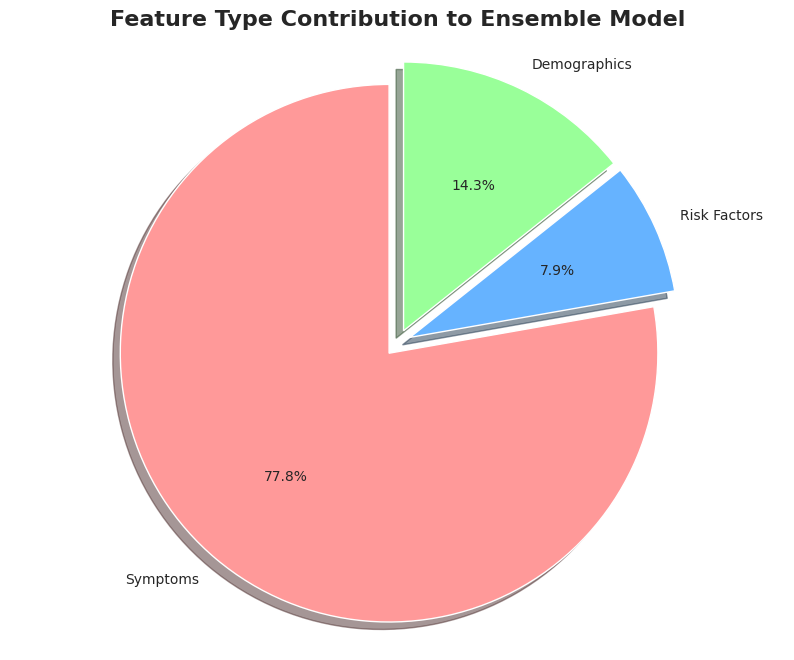

In [10]:
symptom_features = ['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations',
                   'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea']
risk_factor_features = ['High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity',
                       'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress']
demographic_features = ['Gender', 'Age']

rf_model = calibrated_ensemble.calibrated_classifiers_[0].estimator.named_estimators_['rf']
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

symptom_imp = feat_imp[feat_imp['Feature'].isin(symptom_features)]['Importance'].sum()
risk_imp = feat_imp[feat_imp['Feature'].isin(risk_factor_features)]['Importance'].sum()
demo_imp = feat_imp[feat_imp['Feature'].isin(demographic_features)]['Importance'].sum()

labels = ['Symptoms', 'Risk Factors', 'Demographics']
sizes = [symptom_imp, risk_imp, demo_imp]
colors = ['#ff9999', '#66b3ff', '#99ff99']

plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, shadow=True, startangle=90, explode=(0.05,0.05,0.05))
plt.title('Feature Type Contribution to Ensemble Model', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()

In [11]:
# Predictions
y_pred_ens = calibrated_ensemble.predict(X_test)
y_prob_ens = calibrated_ensemble.predict_proba(X_test)[:, 1]

print("=== Ensemble Performance ===")
print("Accuracy :", accuracy_score(y_test, y_pred_ens))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_ens))
print(classification_report(y_test, y_pred_ens))

=== Ensemble Performance ===
Accuracy : 0.9927619047619047
ROC-AUC  : 0.9994476553287982
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      5250
         1.0       1.00      0.99      0.99      5250

    accuracy                           0.99     10500
   macro avg       0.99      0.99      0.99     10500
weighted avg       0.99      0.99      0.99     10500



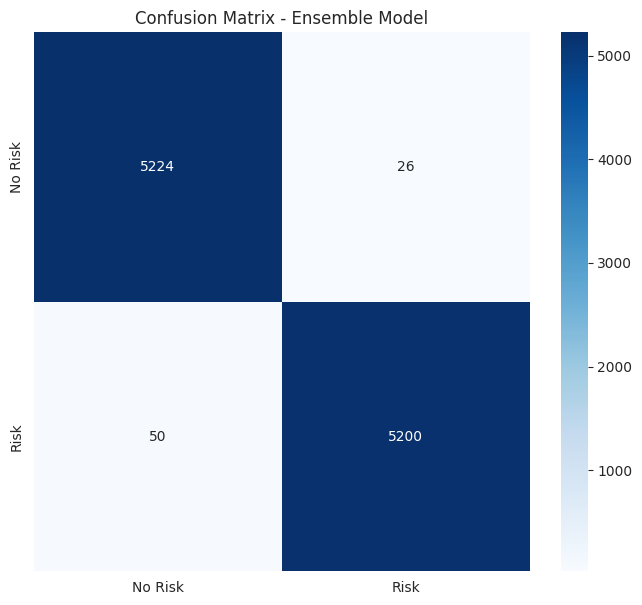

In [12]:
cm = confusion_matrix(y_test, y_pred_ens)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Risk', 'Risk'],
            yticklabels=['No Risk', 'Risk'])
plt.title('Confusion Matrix - Ensemble Model')
plt.show()

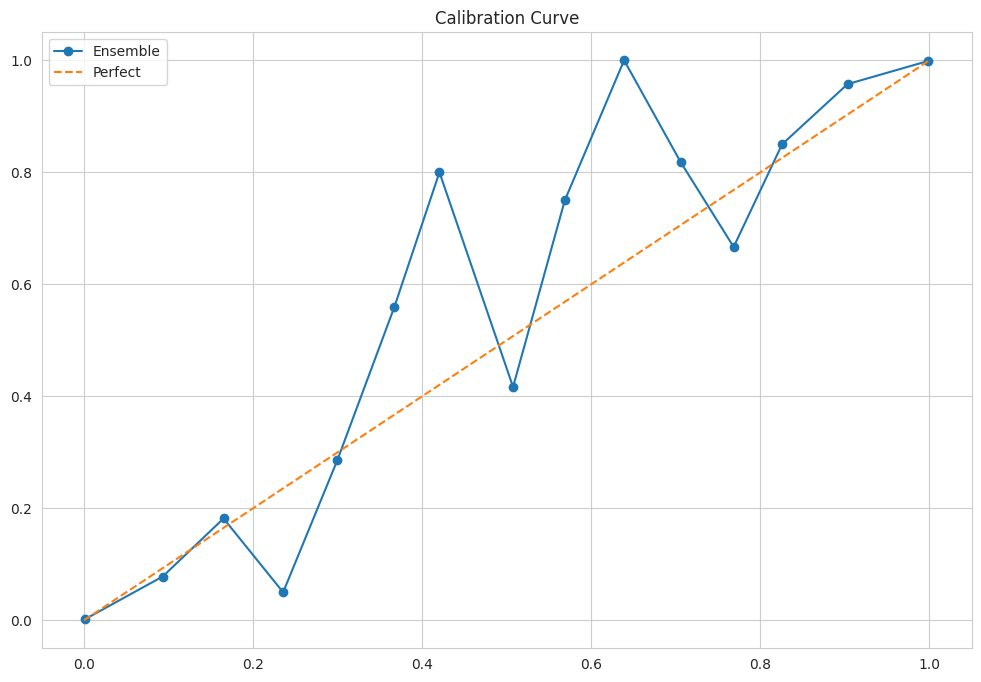

In [13]:
prob_true, prob_pred = calibration_curve(y_test, y_prob_ens, n_bins=15)
plt.plot(prob_pred, prob_true, marker='o', label='Ensemble')
plt.plot([0,1],[0,1], '--', label='Perfect')
plt.title('Calibration Curve')
plt.legend()
plt.show()

In [14]:
def fairness_analysis(X_test, y_test, y_prob, sensitive_col):
    X_test = X_test.copy()
    X_test['pred_prob'] = y_prob
    X_test['true'] = y_test.values
    X_test['pred'] = (y_prob >= 0.5).astype(int)

    results = {}
    for name, group in X_test.groupby(sensitive_col):
        results[name] = {
            'Count': len(group),
            'Accuracy': accuracy_score(group['true'], group['pred']),
            'ROC_AUC': roc_auc_score(group['true'], group['pred_prob']),
            'Mean_Pred_Prob': group['pred_prob'].mean(),
            'Positive_Rate': group['pred'].mean()
        }
    return pd.DataFrame(results).round(4).T

print("=== FAIRNESS BY GENDER ===")
print(fairness_analysis(X_test, y_test, y_prob_ens, 'Gender'))

# Age Group Fairness
X_test_age = X_test.copy()
X_test_age['Age_Group'] = pd.cut(X_test_age['Age'], bins=[0,30,45,60,75,100],
                                 labels=['<30','30-45','46-60','61-75','>75'])
print("\n=== FAIRNESS BY AGE GROUP ===")
print(fairness_analysis(X_test_age, y_test, y_prob_ens, 'Age_Group'))

=== FAIRNESS BY GENDER ===
      Count  Accuracy  ROC_AUC  Mean_Pred_Prob  Positive_Rate
0.0  4722.0    0.9939   0.9993          0.3493         0.3475
1.0  5778.0    0.9919   0.9995          0.6209         0.6205

=== FAIRNESS BY AGE GROUP ===
        Count  Accuracy  ROC_AUC  Mean_Pred_Prob  Positive_Rate
<30    1199.0    1.0000      NaN          0.0005         0.0000
30-45  1721.0    0.9977   1.0000          0.0868         0.0854
46-60  3495.0    0.9866   0.9989          0.5599         0.5588
61-75  2981.0    0.9916   0.9990          0.6799         0.6783
>75    1104.0    1.0000      NaN          0.9992         1.0000


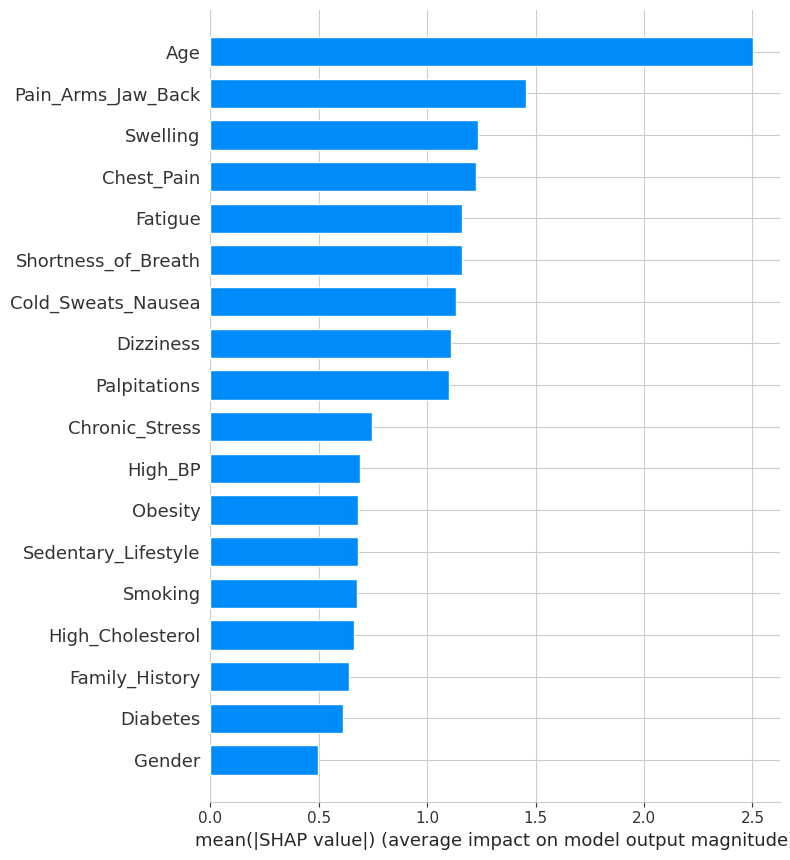

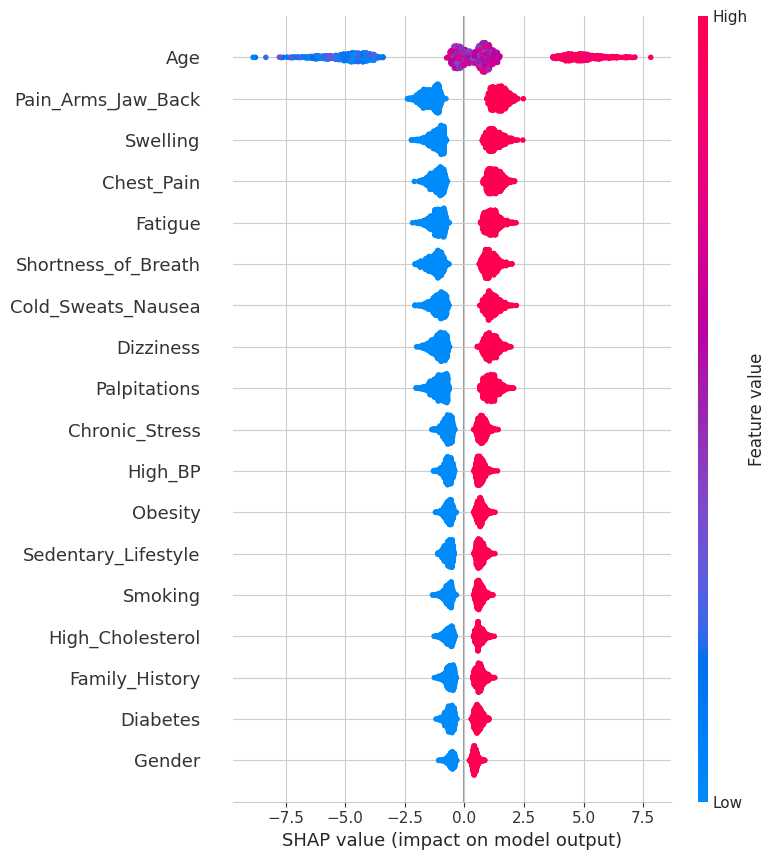

In [15]:
# SHAP Analysis
explainer = shap.TreeExplainer(xgb_model)
X_sample = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, plot_type="bar")
shap.summary_plot(shap_values, X_sample)

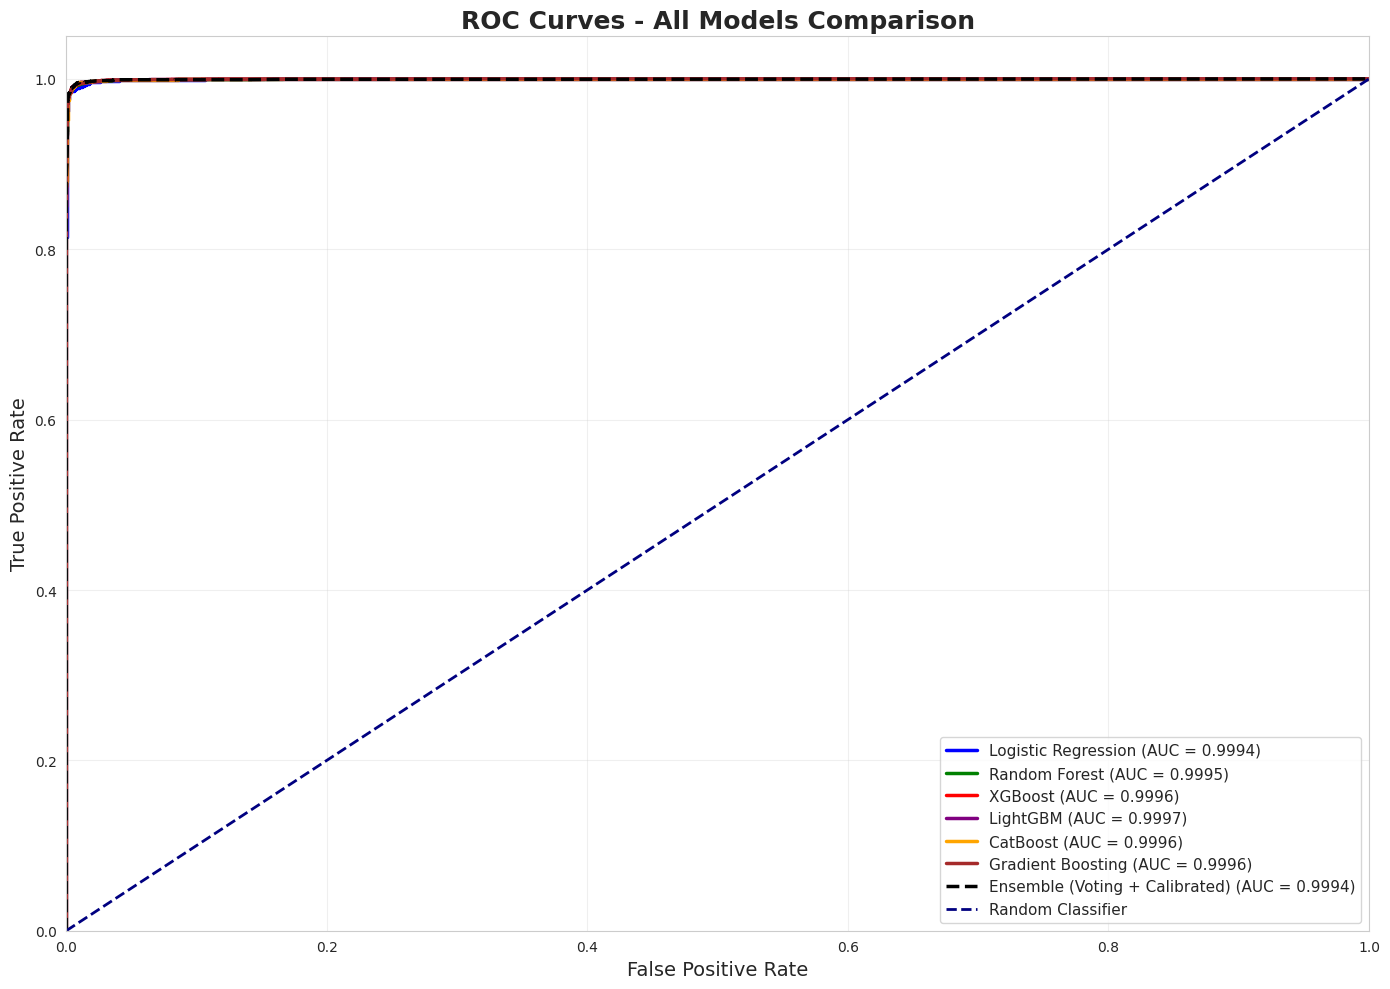

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(14, 10))

# Colors for different models
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'black']
linestyles = ['-', '-', '-', '-', '-', '-', '--']  # Dashed for Ensemble

for (name, model), color, ls in zip(models.items(), colors, linestyles):
    # Get predictions
    if name == "Ensemble (Voting + Calibrated)":
        y_prob = calibrated_ensemble.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, color=color, linestyle=ls, lw=2.5,
             label=f'{name} (AUC = {roc_auc:.4f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curves - All Models Comparison', fontsize=18, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

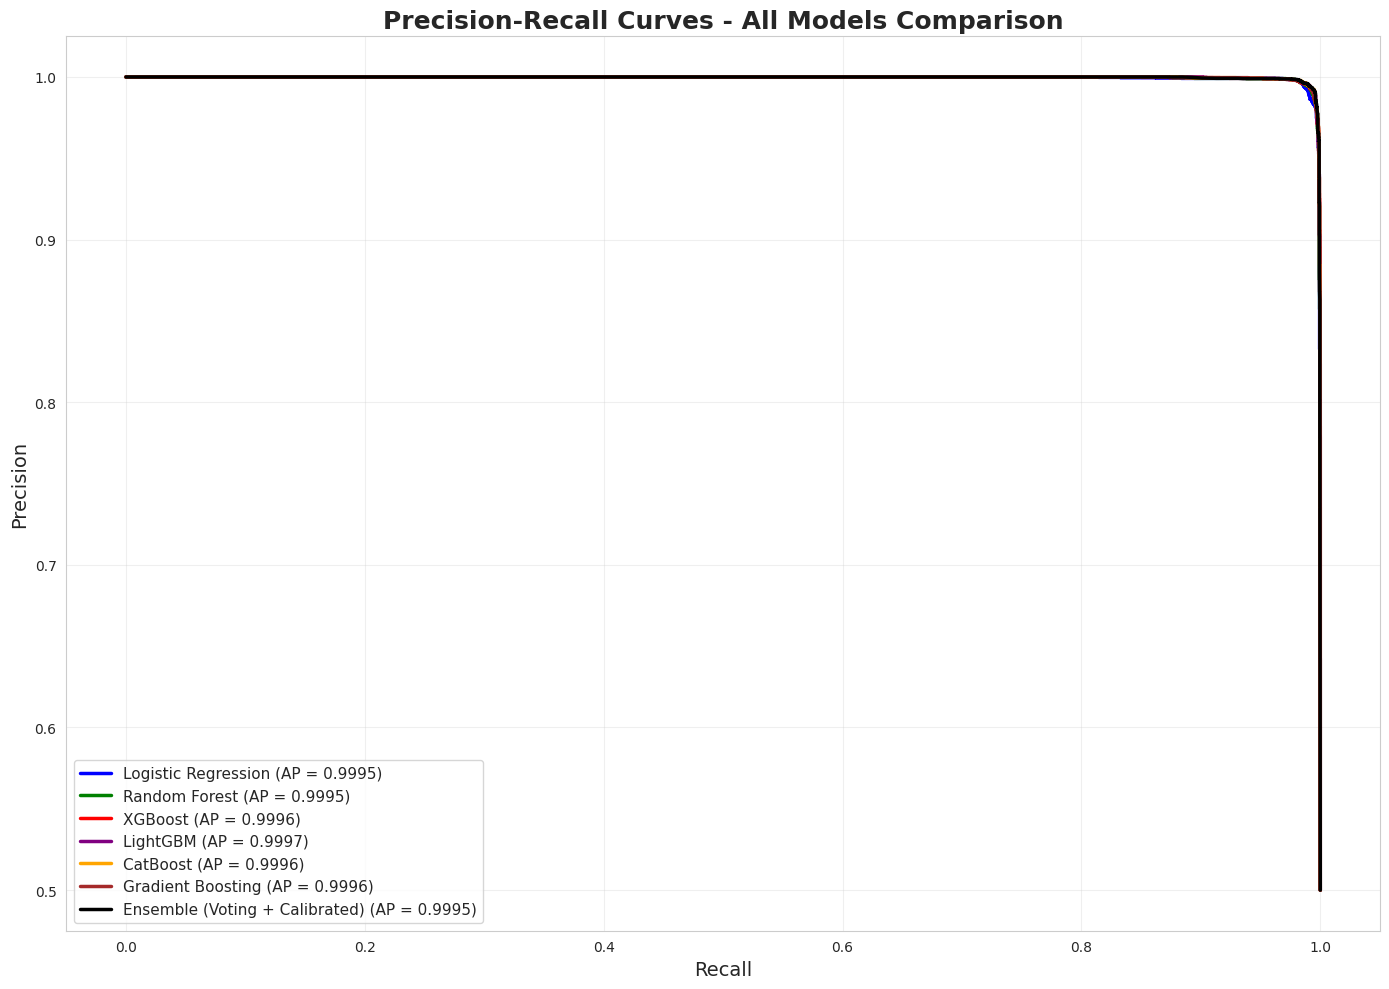

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(14, 10))

colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'black']

for (name, model), color in zip(models.items(), colors):
    if name == "Ensemble (Voting + Calibrated)":
        y_prob = calibrated_ensemble.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)

    plt.plot(recall, precision, color=color, lw=2.5,
             label=f'{name} (AP = {avg_precision:.4f})')

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('Precision-Recall Curves - All Models Comparison', fontsize=18, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

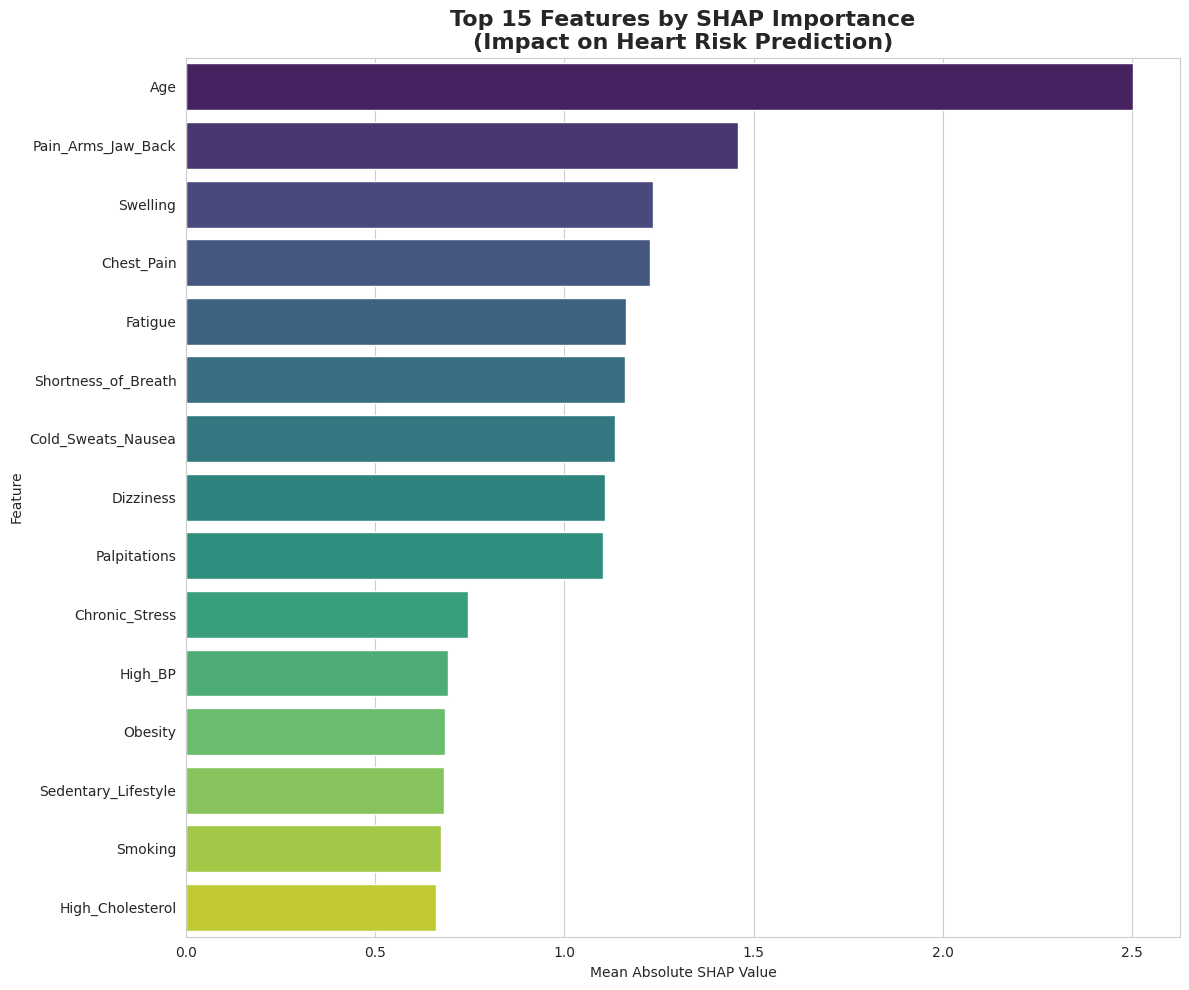

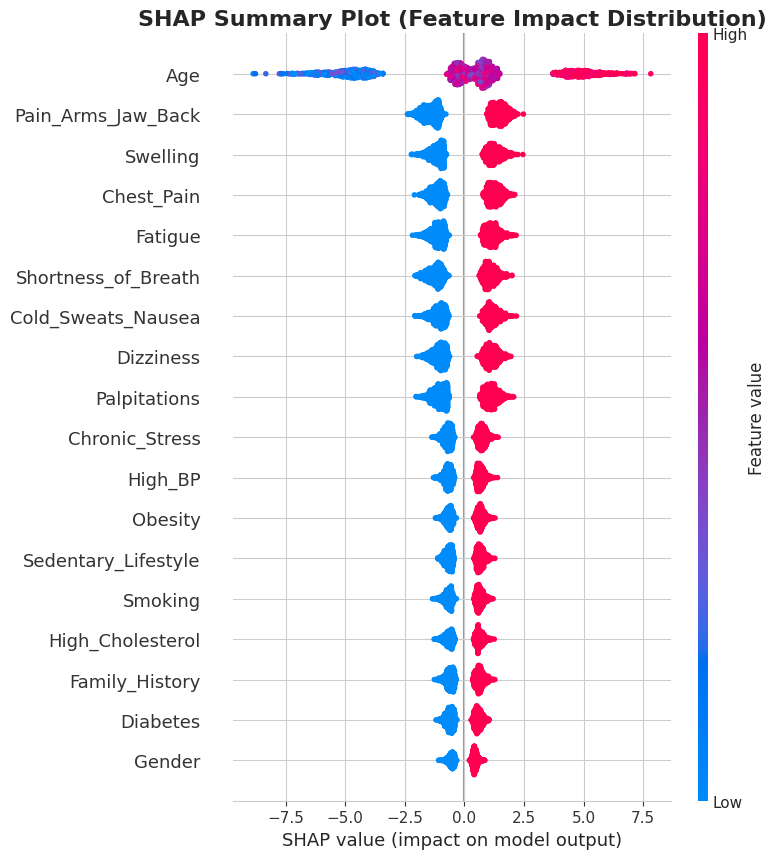

In [18]:
import shap
import matplotlib.pyplot as plt

# Use XGBoost model (best for SHAP)
explainer = shap.TreeExplainer(xgb_model)

# Sample data for faster computation
np.random.seed(42)
X_sample = X_test.sample(2000, random_state=42)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# ==================== Top 15 Features Bar Plot ====================
shap_importance = pd.DataFrame({
    'Feature': X.columns,
    'Mean_Abs_SHAP': np.abs(shap_values).mean(0)
}).sort_values('Mean_Abs_SHAP', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='Mean_Abs_SHAP', y='Feature',
            data=shap_importance.head(15),
            palette='viridis')

plt.title('Top 15 Features by SHAP Importance\n(Impact on Heart Risk Prediction)',
          fontsize=16, fontweight='bold')
plt.xlabel('Mean Absolute SHAP Value')
plt.tight_layout()
plt.show()

# ==================== SHAP Summary Plot (Beeswarm) ====================
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, plot_type="dot", show=False)
plt.title('SHAP Summary Plot (Feature Impact Distribution)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()